# Skin Lesion — Data Preprocessing and MLP Training

**Student:** !TODO

**Group:** Group 1 — Informatyka, Uczenie maszynowe

**Course:** Machine Learning

**Date:** 2026-06-05

This notebook prepares the HAM10000/ISIC training and test sets, preprocesses images for an MLP, trains a model, and evaluates with confusion matrix and weighted F1-score. The final cell is prepared for evaluation on the hidden test set.

## 1. Imports & Setup

In [1]:
import os
import glob
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
import cv2
from skimage.feature import local_binary_pattern

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Flatten, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, f1_score, classification_report

USE_GPU = len(tf.config.list_physical_devices('GPU')) > 0
DEVICE_NAME = '/GPU:0' if USE_GPU else '/CPU:0'
print(f"Using {'GPU' if USE_GPU else 'CPU'}: {DEVICE_NAME}")
print(f"TensorFlow version: {tf.__version__}")

Using GPU: /GPU:0
TensorFlow version: 2.18.0


## 2. Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
TRAIN_META    = 'data/HAM10000_metadata'
TEST_META     = 'data/ISIC2018_Task3_Test_GroundTruth.csv'
TRAIN_FOLDERS = ['data/HAM10000_images_part_1', 'data/HAM10000_images_part_2']
TEST_FOLDER   = 'data/ISIC2018_Task3_Test_Images'

# ── Image parameters ───────────────────────────────────────────────────────
IMG_WIDTH  = 128
IMG_HEIGHT = 128

# ── PCA ────────────────────────────────────────────────────────────────────
PCA_COMPONENTS = 256  

# ── Training ───────────────────────────────────────────────────────────────
EPOCHS      = 100
BATCH_SIZE  = 64 if USE_GPU else 32
RANDOM_SEED = 42
VAL_SPLIT   = 0.2

# ── Artifact paths ─────────────────────────────────────────────────────────
MODEL_PATH   = 'best_mlp_model.keras'
PCA_PATH     = 'pca.pkl'
SCALER_PATH  = 'feature_scaler.pkl'

# Class names
CLASS_NAMES = ['Melanocytic nevi (nv)', 'Melanoma (mel)', 'Others']
NUM_CLASSES = 3

## 3. Data Loading

In [3]:
train_df = pd.read_csv(TRAIN_META)
test_df  = pd.read_csv(TEST_META)

print("Train columns:", train_df.columns.tolist())
print("Test  columns:", test_df.columns.tolist())
train_df.head()

Train columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']
Test  columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [4]:
def build_path_map(folders):
    paths = {}
    for folder in folders:
        for f in glob.glob(os.path.join(folder, '*.jpg')):
            paths[os.path.splitext(os.path.basename(f))[0]] = f
    return paths

train_path_map = build_path_map(TRAIN_FOLDERS)
test_path_map  = build_path_map([TEST_FOLDER])

train_df['path'] = train_df['image_id'].map(train_path_map.get)
test_df['path']  = test_df['image_id'].map(test_path_map.get)

train_df = train_df.dropna(subset=['path'])
test_df  = test_df.dropna(subset=['path'])

print(f"Train images found: {len(train_df)}")
print(f"Test  images found: {len(test_df)}")

def map_labels(dx):
    if dx == 'nv':  return 0  # Melanocytic nevi
    elif dx == 'mel': return 1  # Melanoma
    else: return 2  # Others

train_df['label'] = train_df['dx'].apply(map_labels)
test_df['label']  = test_df['dx'].apply(map_labels)

print("\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print("\nTest label distribution:")
print(test_df['label'].value_counts().sort_index())

Train images found: 10015
Test  images found: 1511

Train label distribution:
label
0    6705
1    1113
2    2197
Name: count, dtype: int64

Test label distribution:
label
0    908
1    171
2    432
Name: count, dtype: int64


## 4. Data Preprocessing

- **RGB** images — colour is diagnostically critical for skin lesion classification
- **HSV + LBP feature engineering** — per-channel colour histograms in RGB and HSV
  spaces, per-channel statistics, and LBP texture histogram; these give the MLP
  colour/texture information that PCA on raw pixels cannot fully recover
- **PCA** to 256 components on raw pixels — reduces 49 152 features, limits overfitting
- **Feature concatenation**: PCA(pixels) + handcrafted features → richer MLP input
- **Data augmentation** applied only to minority training classes (mel, others);
  originals are kept separate so the validation set is never augmented

In [5]:
# ── Handcrafted feature extractor ──────────────────────────────────────────
def extract_features(img_arr):
    """
    Extract colour and texture features from an RGB image.
    img_arr : (H, W, 3) float32 in [0, 1]

    Features (268-dim total):
      - RGB histograms  : 3 channels × 32 bins = 96
      - HSV histograms  : 3 channels × 32 bins = 96
      - RGB statistics  : mean + std per channel = 6
      - HSV statistics  : mean + std per channel = 6
      - LBP histogram   : 64 bins  (uniform LBP, R=1, P=8)
    """
    img_uint8 = (img_arr * 255).astype(np.uint8)
    hsv  = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2HSV)
    gray = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2GRAY)

    feats = []

    # Colour histograms — RGB and HSV
    for ch in range(3):
        h_rgb = np.histogram(img_arr[:, :, ch], bins=32, range=(0, 1))[0].astype(np.float32)
        h_hsv = np.histogram(hsv[:, :, ch],     bins=32)[0].astype(np.float32)
        feats.extend(h_rgb / (h_rgb.sum() + 1e-8))
        feats.extend(h_hsv / (h_hsv.sum() + 1e-8))

    # Per-channel statistics
    for ch in range(3):
        feats.append(img_arr[:, :, ch].mean())
        feats.append(img_arr[:, :, ch].std())
    for ch in range(3):
        c = hsv[:, :, ch].astype(np.float32) / 255.0
        feats.append(c.mean())
        feats.append(c.std())

    # LBP texture histogram — captures lesion border/surface patterns
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist = np.histogram(lbp, bins=64, range=(0, 64))[0].astype(np.float32)
    feats.extend(lbp_hist / (lbp_hist.sum() + 1e-8))

    return np.array(feats, dtype=np.float32)   # 268-dim


# ── Image loader with augmentation ─────────────────────────────────────────
def load_images_rgb(df, augment=False, augment_minority_factor=3):
    """
    Load images as RGB arrays normalised to [0, 1].
    When augment=True, minority classes (mel=1, others=2) are augmented
    augment_minority_factor times. Originals are always kept separate so
    the validation set is never contaminated with augmented samples.

    Returns:
        images_orig  : (N_orig, H*W*3)  raw pixels, originals only
        feats_orig   : (N_orig, 268)    handcrafted features, originals only
        labels_orig  : (N_orig,)
        images_all   : (N_aug, H*W*3)   originals + augmented
        feats_all    : (N_aug, 268)
        labels_all   : (N_aug,)
    """
    datagen = ImageDataGenerator(
        horizontal_flip=True,
        vertical_flip=True,
        rotation_range=20,
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        brightness_range=[0.85, 1.15],
    )

    images_orig, feats_orig, labels_orig = [], [], []
    images_aug,  feats_aug,  labels_aug  = [], [], []

    for _, row in df.iterrows():
        try:
            img = Image.open(row['path']).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))
            arr = np.array(img, dtype=np.float32) / 255.0

            images_orig.append(arr)
            feats_orig.append(extract_features(arr))
            labels_orig.append(row['label'])

            if augment and row['label'] in [1, 2]:
                arr_4d   = arr[np.newaxis]
                aug_iter = datagen.flow(arr_4d, batch_size=1)
                for _ in range(augment_minority_factor):
                    aug_img = np.clip(next(aug_iter)[0], 0.0, 1.0)
                    images_aug.append(aug_img)
                    feats_aug.append(extract_features(aug_img))
                    labels_aug.append(row['label'])

        except Exception as e:
            print(f"Error loading {row['path']}: {e}")

    images_orig = np.array(images_orig, dtype=np.float32)
    feats_orig  = np.array(feats_orig,  dtype=np.float32)
    labels_orig = np.array(labels_orig, dtype=np.int32)

    if images_aug:
        images_all = np.concatenate([images_orig, np.array(images_aug, dtype=np.float32)], axis=0)
        feats_all  = np.concatenate([feats_orig,  np.array(feats_aug,  dtype=np.float32)], axis=0)
        labels_all = np.concatenate([labels_orig, np.array(labels_aug, dtype=np.int32)],   axis=0)
    else:
        images_all = images_orig
        feats_all  = feats_orig
        labels_all = labels_orig

    return (images_orig.reshape(len(images_orig), -1), feats_orig, labels_orig,
            images_all.reshape(len(images_all),   -1), feats_all,  labels_all)


print("Loading & augmenting training images (minority classes only)...")
X_train_orig, F_train_orig, y_train_orig, X_train_raw, F_train_raw, y_train = \
    load_images_rgb(train_df, augment=True, augment_minority_factor=3)

print("Loading test images (no augmentation)...")
X_test_orig, F_test, y_test, _, _, _ = load_images_rgb(test_df, augment=False)

print(f"\nOriginal train  : {X_train_orig.shape}")
print(f"Augmented train : {X_train_raw.shape}")
print(f"Test images     : {X_test_orig.shape}")
print(f"Train label distribution after augmentation: {np.bincount(y_train)}")

Loading & augmenting training images (minority classes only)...
Loading test images (no augmentation)...

Original train  : (10015, 49152)
Augmented train : (19945, 49152)
Test images     : (1511, 49152)
Train label distribution after augmentation: [6705 4452 8788]


In [6]:
# ── PCA on raw pixels ──────────────────────────────────────────────────────
print(f"Fitting PCA ({PCA_COMPONENTS} components) on augmented training data...")
pca = PCA(n_components=PCA_COMPONENTS, random_state=RANDOM_SEED)

X_train_pca      = pca.fit_transform(X_train_raw)    # full augmented pool → train
X_train_orig_pca = pca.transform(X_train_orig)        # originals only     → val
X_test_pca       = pca.transform(X_test_orig)

explained = np.sum(pca.explained_variance_ratio_) * 100
print(f"PCA explains {explained:.1f}% of variance with {PCA_COMPONENTS} components")

# ── Standardise handcrafted features (fit on originals to avoid aug leakage) ──
scaler = StandardScaler()
F_train_orig_sc = scaler.fit_transform(F_train_orig)   # fit on originals only
F_train_raw_sc  = scaler.transform(F_train_raw)         # apply to full aug pool
F_test_sc       = scaler.transform(F_test)

# ── Concatenate PCA pixels + handcrafted features ──────────────────────────
X_train_combined      = np.concatenate([X_train_pca,      F_train_raw_sc],  axis=1)
X_train_orig_combined = np.concatenate([X_train_orig_pca, F_train_orig_sc], axis=1)
X_test_combined       = np.concatenate([X_test_pca,       F_test_sc],       axis=1)

INPUT_DIM = X_train_combined.shape[1]   # PCA_COMPONENTS + 268
print(f"\nCombined feature dim : {INPUT_DIM}")
print(f"X_train_combined     : {X_train_combined.shape}")
print(f"X_test_combined      : {X_test_combined.shape}")

# Save preprocessing artefacts needed for hidden-test evaluation
with open(PCA_PATH,    'wb') as f: pickle.dump(pca,    f)
with open(SCALER_PATH, 'wb') as f: pickle.dump(scaler, f)
print(f"PCA saved    → '{PCA_PATH}'")
print(f"Scaler saved → '{SCALER_PATH}'")

Fitting PCA (256 components) on augmented training data...
PCA explains 99.7% of variance with 256 components

Combined feature dim : 524
X_train_combined     : (19945, 524)
X_test_combined      : (1511, 524)
PCA saved    → 'pca.pkl'
Scaler saved → 'feature_scaler.pkl'


## 5. Train / Validation Split

Train set: full augmented pool. Val set: original (non-augmented) images only.
Class weights are computed on the original pre-augmentation labels from `train_df`
to avoid double-penalising the majority class.

In [7]:
# Val from originals only; train from full augmented pool
_, X_val, _, y_val = train_test_split(
    X_train_orig_combined, y_train_orig,
    test_size=VAL_SPLIT,
    random_state=RANDOM_SEED,
    stratify=y_train_orig
)

X_tr = X_train_combined
y_tr = y_train

y_tr_cat  = to_categorical(y_tr,  num_classes=NUM_CLASSES)
y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)

# Class weights from ORIGINAL labels (pre-augmentation).
# sqrt-softened: dampens extreme weights that double-penalise majority class
# when minority classes have already been inflated by augmentation.
cw_raw = compute_class_weight(
    'balanced',
    classes=np.array([0, 1, 2]),
    y=train_df['label'].values
)
class_weight_dict = {i: float(np.sqrt(w)) for i, w in enumerate(cw_raw)}

print(f"Train split : {X_tr.shape}")
print(f"Val   split : {X_val.shape}")
print(f"Class weights (sqrt-softened, pre-aug labels): {class_weight_dict}")


# ── Focal loss ─────────────────────────────────────────────────────────────
def focal_loss(gamma=2.0):
    """
    Focal loss for multi-class classification.
    Focuses training on hard/misclassified examples by down-weighting
    confident correct predictions. Particularly effective when one class
    (mel) is chronically underlearned.
    gamma=2.0 is the standard value from the original paper.
    """
    def loss_fn(y_true, y_pred):
        y_pred  = tf.clip_by_value(y_pred, 1e-8, 1.0)
        ce      = -y_true * tf.math.log(y_pred)
        p_t     = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        weight  = tf.pow(1.0 - p_t, gamma)
        return tf.reduce_mean(tf.reduce_sum(weight * ce, axis=-1))
    return loss_fn

Train split : (19945, 524)
Val   split : (2003, 524)
Class weights (sqrt-softened, pre-aug labels): {0: 0.7056111881864263, 1: 1.7318778878052987, 2: 1.2326784993703315}


## 6. Model Design

Input dimension = PCA(256) + handcrafted features(268) = 524.

Design choices:
- **Dropout re-enabled** at every layer (was missing in last two layers)
- **BatchNormalization(momentum=0.9)** — faster adaptation vs default 0.99,
  reduces instability from augmented batch diversity
- **Decreasing dropout** (0.35 → 0.3 → 0.2 → 0.15)
- **Focal loss** used instead of cross-entropy — focuses training on hard
  examples (especially mel), improving recall on minority classes

In [8]:
def build_mlp(input_dim, num_classes):
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(256, activation='relu'),
        BatchNormalization(momentum=0.9),
        Dropout(0.35),

        Dense(128, activation='relu'),
        BatchNormalization(momentum=0.9),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(momentum=0.9),
        Dropout(0.2),

        Dense(32, activation='relu'),
        BatchNormalization(momentum=0.9),
        Dropout(0.15),

        Dense(num_classes, activation='softmax')
    ])
    return model

with tf.device(DEVICE_NAME):
    model = build_mlp(INPUT_DIM, NUM_CLASSES)

model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss=focal_loss(gamma=2.0),
    metrics=['accuracy']
)

model.summary()

2026-06-07 19:32:49.005842: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-06-07 19:32:49.016490: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-06-07 19:32:49.017919: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1780853569.018746 3702095 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780853569.020241 3702095 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       134,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 179,651 (701.76 KB)

 Trainable params: 178,691 (698.01 KB)

 Non-trainable params: 960 (3.75 KB)

## 7. Model Training

**Hyperparameters:**
- Optimizer: Adam, initial LR = 5e-5
- Loss: Focal loss (gamma=2.0)
- LR schedule: ReduceLROnPlateau (factor=0.5, patience=5, min_lr=1e-7)
- Early stopping: patience=15 (gives LR scheduler time to recover)
- Batch size: 64 (GPU) / 32 (CPU)
- Class weights: sqrt-softened balanced weights from original pre-augmentation labels

In [9]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=15,
        restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        MODEL_PATH, monitor='val_loss',
        save_best_only=True, verbose=0
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-7, verbose=1
    ),
]

print("Starting training...")
with tf.device(DEVICE_NAME):
    history = model.fit(
        X_tr, y_tr_cat,
        validation_data=(X_val, y_val_cat),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

print("Training complete.")

Starting training...
Epoch 1/100


2026-06-07 19:32:51.170844: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


312/312 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4996 - loss: 0.9080 - val_accuracy: 0.6730 - val_loss: 0.3887 - learning_rate: 5.0000e-05
Epoch 2/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.5550 - loss: 0.6516 - val_accuracy: 0.6730 - val_loss: 0.3640 - learning_rate: 5.0000e-05
Epoch 3/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.5781 - loss: 0.5522 - val_accuracy: 0.6740 - val_loss: 0.3288 - learning_rate: 5.0000e-05
Epoch 4/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.5803 - loss: 0.5069 - val_accuracy: 0.6905 - val_loss: 0.2915 - learning_rate: 5.0000e-05
Epoch 5/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5888 - loss: 0.4763 - val_accuracy: 0.6885 - val_loss: 0.3035 - learning_rate: 5.0000e-05
Epoch 6/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.6001 - loss: 0.4436 - val_accuracy: 0.6950 - val_loss: 0.2852 - learning_rate: 5.0000e-05
Epoch 7/100
312/312 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - a

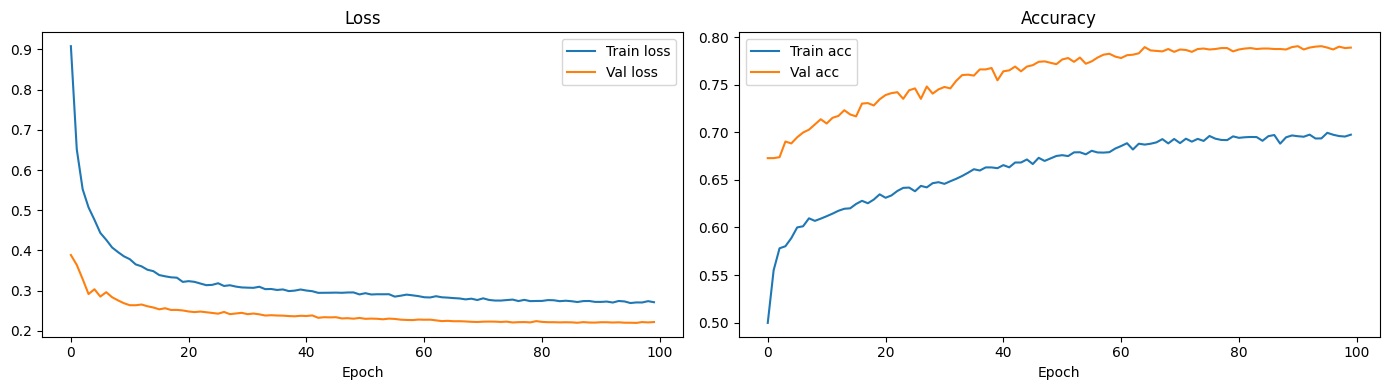

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train acc')
axes[1].plot(history.history['val_accuracy'], label='Val acc')
axes[1].set_title('Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Model Evaluation on Test Set

Evaluation includes threshold tuning on the validation set: instead of plain
`argmax`, per-class thresholds are searched to maximise weighted F1, then
applied to test set predictions.

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Tuning thresholds on validation set...
Best val thresholds : [0.3, 0.1, 0.2]
Best val weighted F1: 0.7905

Classification Report:
                       precision    recall  f1-score   support

Melanocytic nevi (nv)       0.83      0.83      0.83       908
       Melanoma (mel)       0.36      0.47      0.41       171
               Others       0.70      0.63      0.66       432

             accuracy                           0.73      1511
            macro avg       0.63      0.64      0.63      1511
         weighted avg       0.74      0.73      0.73      1511

Weighted F1-score : 0.7348
Macro    F1-score : 0.6335

Confusion Matrix:
[[751  82  75]
 [ 51  80  40]
 [ 99  61 272]]


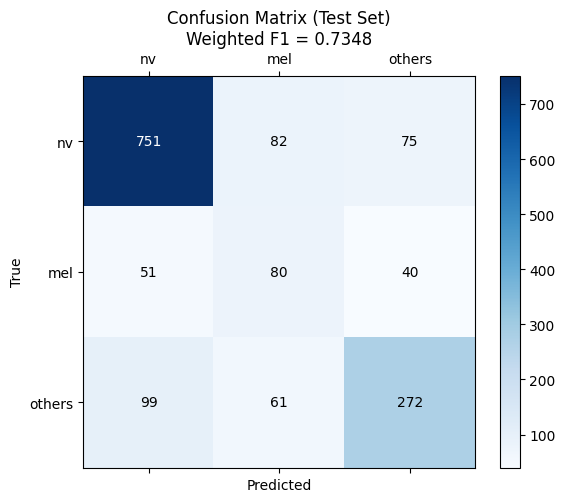

In [11]:
best_model = load_model(MODEL_PATH, custom_objects={'loss_fn': focal_loss(gamma=2.0)})

# ── Threshold tuning on validation set ─────────────────────────────────────
def tune_thresholds(y_true, y_probs, num_classes=3, step=0.05):
    """
    Grid-search per-class classification thresholds on the val set.
    Prediction: class with highest (prob - threshold) margin.
    Optimises weighted F1.
    """
    best_thresholds = [1 / num_classes] * num_classes
    best_f1 = 0.0
    thresholds_range = np.arange(0.1, 0.7, step)

    for t0 in thresholds_range:
        for t1 in thresholds_range:
            for t2 in thresholds_range:
                t = np.array([t0, t1, t2])
                preds = np.argmax(y_probs - t, axis=1)
                f1 = f1_score(y_true, preds, average='weighted')
                if f1 > best_f1:
                    best_f1 = f1
                    best_thresholds = t.tolist()

    print(f"Best val thresholds : {[round(t,2) for t in best_thresholds]}")
    print(f"Best val weighted F1: {best_f1:.4f}")
    return best_thresholds

with tf.device(DEVICE_NAME):
    val_probs  = best_model.predict(X_val,            batch_size=BATCH_SIZE)
    test_probs = best_model.predict(X_test_combined,  batch_size=BATCH_SIZE)

print("\nTuning thresholds on validation set...")
thresholds = tune_thresholds(y_val, val_probs)

# Apply tuned thresholds to test predictions
y_pred_classes = np.argmax(test_probs - np.array(thresholds), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_classes, target_names=CLASS_NAMES))

f1_weighted = f1_score(y_test, y_pred_classes, average='weighted')
f1_macro    = f1_score(y_test, y_pred_classes, average='macro')
print(f"Weighted F1-score : {f1_weighted:.4f}")
print(f"Macro    F1-score : {f1_macro:.4f}")

cm = confusion_matrix(y_test, y_pred_classes)
print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.matshow(cm, cmap=plt.cm.Blues)
plt.colorbar(im)
tick_labels = ['nv', 'mel', 'others']
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(tick_labels)
ax.set_yticklabels(tick_labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix (Test Set)\nWeighted F1 = {f1_weighted:.4f}')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.tight_layout()
plt.show()

---
## 9. Final Evaluation Cell

*The cell below is prepared for the evaluation of the model on an unseen hidden dataset.*

*Set `HIDDEN_TEST_CSV` and `HIDDEN_TEST_IMG_DIR` to the correct paths before running.*

**Artefacts required** (all saved during training):
- `best_mlp_model.keras` — trained model
- `pca.pkl` — PCA fitted on training pixels
- `feature_scaler.pkl` — StandardScaler fitted on training handcrafted features

The hidden test images are processed with the identical pipeline:
RGB → resize → normalise → PCA → handcrafted features → scale → concatenate → predict.

In [12]:
# ==========================================
# HIDDEN TEST SET EVALUATION
# ==========================================
HIDDEN_TEST_CSV     = 'path/to/hidden_test_labels.csv'
HIDDEN_TEST_IMG_DIR = 'path/to/hidden_test_images'


def evaluate_hidden_dataset(
    csv_path,
    img_dir,
    model_path  = MODEL_PATH,
    pca_path    = PCA_PATH,
    scaler_path = SCALER_PATH
):
    """
    Evaluate the saved model on a hidden test set.
    Applies the SAME preprocessing pipeline used during training:
      RGB → resize → normalise → flatten
        → PCA (from pca.pkl)
        → extract_features (HSV + LBP)
        → StandardScaler (from feature_scaler.pkl)
        → concatenate → predict
    """
    try:
        final_model    = load_model(model_path,
                                    custom_objects={'loss_fn': focal_loss(gamma=2.0)})
        with open(pca_path,    'rb') as f: pca_loaded    = pickle.load(f)
        with open(scaler_path, 'rb') as f: scaler_loaded = pickle.load(f)
    except FileNotFoundError as e:
        print(f"Could not load model or preprocessing artefacts: {e}")
        return

    try:
        hidden_df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"CSV not found: {csv_path}")
        return

    images_flat, hand_feats, labels = [], [], []

    for _, row in hidden_df.iterrows():
        img_path = os.path.join(img_dir, row['image_id'] + '.jpg')
        if not os.path.exists(img_path):
            continue
        try:
            img = Image.open(img_path).convert('RGB')
            img = img.resize((IMG_WIDTH, IMG_HEIGHT))
            arr = np.array(img, dtype=np.float32) / 255.0
            images_flat.append(arr.flatten())
            hand_feats.append(extract_features(arr))
            labels.append(map_labels(row['dx']))
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    if not images_flat:
        print("No images loaded — check HIDDEN_TEST_IMG_DIR and CSV image_id values.")
        return

    X_hidden_px    = np.array(images_flat, dtype=np.float32)
    X_hidden_feats = np.array(hand_feats,  dtype=np.float32)
    y_hidden       = np.array(labels,      dtype=np.int32)

    # Apply the SAME transforms fitted on training data
    X_hidden_pca      = pca_loaded.transform(X_hidden_px)
    X_hidden_feats_sc = scaler_loaded.transform(X_hidden_feats)
    X_hidden_combined = np.concatenate([X_hidden_pca, X_hidden_feats_sc], axis=1)

    with tf.device(DEVICE_NAME):
        y_pred_probs = final_model.predict(X_hidden_combined, batch_size=BATCH_SIZE)

    # Apply thresholds tuned on val set (from cell 19)
    y_pred_classes = np.argmax(y_pred_probs - np.array(thresholds), axis=1)

    print("\nClassification Report (Hidden Set):")
    print(classification_report(y_hidden, y_pred_classes, target_names=CLASS_NAMES))

    f1_w = f1_score(y_hidden, y_pred_classes, average='weighted')
    f1_m = f1_score(y_hidden, y_pred_classes, average='macro')
    print(f"Weighted F1-score : {f1_w:.4f}")
    print(f"Macro    F1-score : {f1_m:.4f}")

    cm_h = confusion_matrix(y_hidden, y_pred_classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.matshow(cm_h, cmap=plt.cm.Blues)
    plt.colorbar(im)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(['nv', 'mel', 'others'])
    ax.set_yticklabels(['nv', 'mel', 'others'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    ax.set_title(f'Confusion Matrix (Hidden Set)\nWeighted F1 = {f1_w:.4f}')
    for i in range(cm_h.shape[0]):
        for j in range(cm_h.shape[1]):
            ax.text(j, i, str(cm_h[i, j]), ha='center', va='center',
                    color='white' if cm_h[i, j] > cm_h.max() / 2 else 'black')
    plt.tight_layout()
    plt.show()


evaluate_hidden_dataset(HIDDEN_TEST_CSV, HIDDEN_TEST_IMG_DIR)

CSV not found: path/to/hidden_test_labels.csv
